# 🍎 FreshGuard Notebook 03: LSTM Spoilage Forecast

The manager dashboard needs a 7-day forecast of daily flagged-item counts (items graded reject or sell-soon). This notebook covers the full forecasting pipeline:

1. Generates the same simulated scan history the backend uses
2. Trains an LSTM with a 28-day lookback to predict 7 days ahead
3. Benchmarks it against a seasonal-naive baseline
4. Exports the trained model and history so the dashboard switches from the naive fallback to live predictions

> **Note:** The history is simulated and labelled as such in the deck and Q&A.
> In production, real scan logs would replace it once the app has been running in-store.

## ⚙️ Section 1: Setup & Imports

In [13]:
# Colab: uncomment if first run
!pip install -q tensorflow scikit-learn

import joblib
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT       = Path("/content/Deep-Learning-Computer-Vision")
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Forecast hyperparameters ─────────────────────────────────────────────────
WINDOW  = 28   # days the model looks back
HORIZON = 7    # days it predicts forward

print(f"TensorFlow {tf.__version__}")
print(f"Models dir: {MODELS_DIR}  (exists: {MODELS_DIR.exists()})")

TensorFlow 2.20.0
Models dir: /content/Deep-Learning-Computer-Vision/models  (exists: True)


## 📊 Section 2: Simulate History & Export CSV

We generate ~2 years of daily flagged-item counts (reject + sell-soon) using the
same `simulate_history()` function as `backend/forecast.py`. Keeping the seed and
generator in sync ensures the dashboard history chart matches the training data exactly.

The series captures the recurring patterns of a Spanish grocery:
- **Weekly seasonality:** weekend rotation peaks (delivery cycles)
- **Yearly seasonality:** summer freshness pressure
- **Trend:** slow store growth over time

On top of that, three Spain-specific calendar effects are layered in. Each produces a
multi-day signal that a weekly-lag rule structurally misses, but which the LSTM can learn to anticipate:
- **Public holidays:** national closures (Reyes, Asunción, Hispanidad,
  Inmaculada, Navidad, etc.) stall produce rotation; pre-holiday overstock
  and post-closure backlogs inflate the surrounding days
- **End-of-month promotions:** near-expiry loose produce flagged for markdown
  under Law 1/2025, a monthly block that never aligns to the 7-day cycle
- **Summer demand volatility:** the August holiday exodus and tourism swings make
  demand hard to predict; ordering overshoots and overstocked ambient produce builds
  up in irregular 3 to 5 day episodes

> This data is simulated. In production it would be replaced by real scan logs
> once the app has been running in-store.

Exported 730 rows -> /content/Deep-Learning-Computer-Vision/models/scan_history.csv
          date  flagged_items
727 2026-06-11           68.6
728 2026-06-12           60.7
729 2026-06-13           66.0


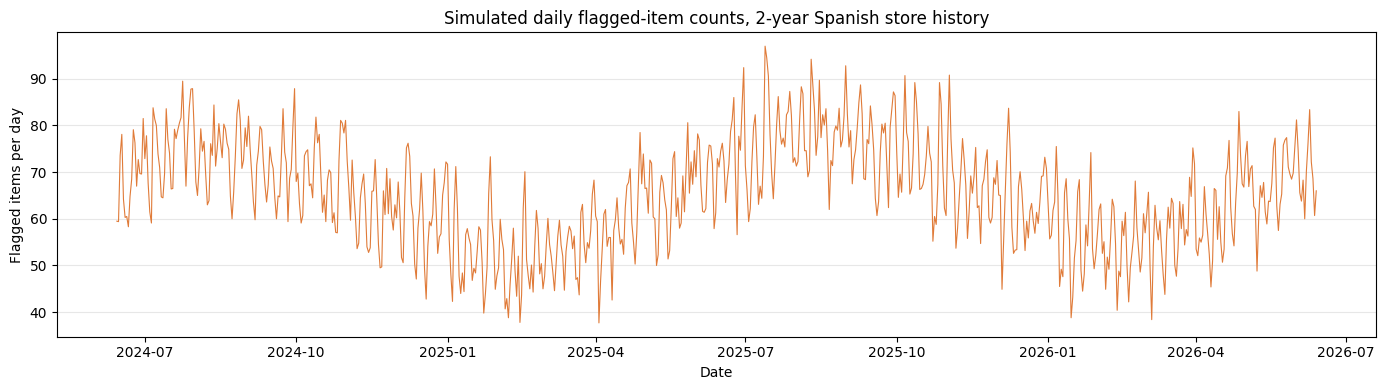

In [14]:
def simulate_history(days: int = 730, seed: int = 42) -> pd.DataFrame:
    """
    Generate a synthetic daily time series of flagged produce items for a
    Spanish supermarket.

    Kept in sync with backend/forecast.py. The seed and generator must match so
    the dashboard history chart has no visible seam.

    The series combines weekly and yearly seasonality and a slow growth trend
    with three Spain-specific multi-day calendar effects: national public
    holidays, end-of-month clearance promotions, and summer demand volatility.
    Each effect persists for several days, giving the LSTM multi-day signals that
    a weekly-lag baseline structurally misses.

    Parameters
    ----------
    days : int
        Number of daily observations to generate.
    seed : int
        RNG seed for reproducibility.

    Returns
    -------
    df : pd.DataFrame
        DataFrame with columns 'date' (datetime) and 'flagged_items' (float).
    """
    rng = np.random.default_rng(seed)
    t = np.arange(days)
    dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=days)

    weekly = 8 * np.sin(2 * np.pi * t / 7 - 1.2)          # weekend rotation peaks
    yearly = 12 * np.sin(2 * np.pi * t / 365 + 0.5)       # summer freshness pressure
    trend = 0.01 * t                                       # store growth
    base = 60
    noise = rng.normal(0, 4, days)

    # Spanish national public holidays (fixed dates). Around a closure, rotation
    # stalls and pre-holiday overstocking inflates the surrounding days.
    holidays_md = {(1, 1), (1, 6), (5, 1), (8, 15), (10, 12),
                   (11, 1), (12, 6), (12, 8), (12, 25)}
    holiday = np.zeros(days)
    for i, d in enumerate(dates):
        if (d.month, d.day) in holidays_md:
            holiday[i] += 14                       # closure-day backlog
            if i + 1 < days:
                holiday[i + 1] += 9                # spillover the day after
            if i - 1 >= 0:
                holiday[i - 1] += 5                # pre-holiday overstock

    # End-of-month clearance promotions: near-expiry loose produce flagged for
    # markdown (Law 1/2025). A ~monthly block never aligns to the 7-day lag.
    promo = np.where(dates.day >= 27, 7.0, 0.0)

    # Summer demand volatility (Jul-Aug): the August holiday exodus and tourism
    # swings make demand hard to predict, so ordering overshoots and overstocked
    # ambient produce sits and gets flagged. Irregular multi-day episodes.
    summer = np.zeros(days)
    summer_idx = np.where(np.isin(dates.month, [7, 8]))[0]
    if len(summer_idx) > 0:
        n_episodes = max(1, len(summer_idx) // 20)
        for s in rng.choice(summer_idx, size=n_episodes, replace=False):
            length = int(rng.integers(3, 6))
            peak = rng.uniform(10, 20)
            for k in range(length):
                if s + k < days:
                    summer[s + k] += peak * (1 - k / length)   # eases as stock clears

    counts = base + weekly + yearly + trend + noise + holiday + promo + summer
    return pd.DataFrame({"date": dates, "flagged_items": counts.clip(min=0).round(1)})


df = simulate_history(days=730, seed=SEED)

# Export: backend/forecast.py picks this up automatically once it exists
df.to_csv(MODELS_DIR / "scan_history.csv", index=False)
print(f"Exported {len(df)} rows -> {MODELS_DIR / 'scan_history.csv'}")
print(df.tail(3))

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"], df["flagged_items"], linewidth=0.8, color="#e07b39")
ax.set_title("Simulated daily flagged-item counts, 2-year Spanish store history")
ax.set_xlabel("Date")
ax.set_ylabel("Flagged items per day")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 🔍 Section 3: Exploratory Look at the Series

Before modelling, we identify the temporal structures the model needs to capture.
These observations justify our architecture and feature choices:

- **Weekly seasonality** (period = 7 days): justifies a 28-day window (4 full weekly cycles)
- **Yearly seasonality + trend:** justifies LSTM over a vanilla RNN, whose vanishing
  gradients struggle with dependencies longer than ~10 steps
- **Calendar shocks** (holidays, end-of-month promotions, summer demand swings):
  these are tied to the calendar, not to the recent counts, so a model that sees only
  past values cannot anticipate them. We therefore feed the LSTM explicit calendar
  features (day-of-week, day-of-year, holiday and promotion flags) alongside the count.
  The weekly-lag baseline has no such inputs and structurally misses the end-of-month
  markdown block; this is where a learned model earns its place over the naive rule.

We keep this section brief. The goal is architectural justification, not a full EDA.

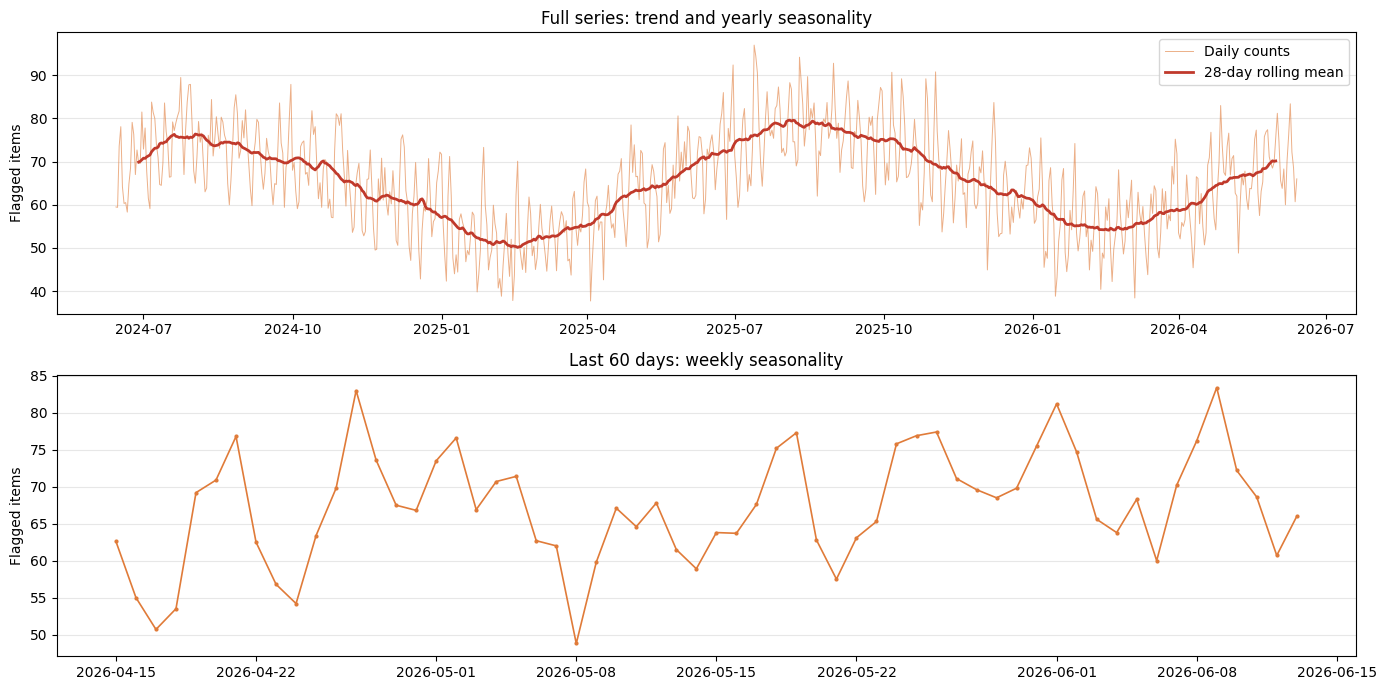

Series length : 730 days
Mean          : 65.4  |  Std: 11.2
Min           : 37.7  |  Max: 97.0


In [15]:
series = df["flagged_items"].values

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# ── Full series with 28-day rolling mean to expose trend + yearly pattern ────
rolling = df["flagged_items"].rolling(28, center=True).mean()
axes[0].plot(df["date"], series, linewidth=0.7, alpha=0.6,
             color="#e07b39", label="Daily counts")
axes[0].plot(df["date"], rolling, linewidth=2,
             color="#c0392b", label="28-day rolling mean")
axes[0].set_title("Full series: trend and yearly seasonality")
axes[0].set_ylabel("Flagged items")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# ── 60-day zoom to expose the weekly cycle ───────────────────────────────────────
axes[1].plot(df["date"].iloc[-60:], series[-60:],
             linewidth=1.2, color="#e07b39", marker="o", markersize=2)
axes[1].set_title("Last 60 days: weekly seasonality")
axes[1].set_ylabel("Flagged items")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Series length : {len(series)} days")
print(f"Mean          : {series.mean():.1f}  |  Std: {series.std():.1f}")
print(f"Min           : {series.min():.1f}  |  Max: {series.max():.1f}")

## ✂️ Section 4: Chronological Split

We split the series into **train (70%) / validation (15%) / test (15%)** strictly by time position: earlier data trains the model, later data evaluates it.

**Never shuffle a time series.** A random split would let the model train on
future observations and validate on past ones: the metrics would look great but
the model would be useless in production (it can't see the future at inference time).

| Split | Portion | Purpose |
|---|---|---|
| Train | Days 1–511 | Model learns the pattern |
| Validation | Days 512–621 | Early stopping & hyperparameter tuning |
| Test | Days 622–730 | Final unbiased evaluation |

Total  : 730 days
Train  : 510 days  (2024-06-14 → 2025-11-05)
Val    : 110 days  (2025-11-06 → 2026-02-23)
Test   : 110 days  (2026-02-24 → 2026-06-13)


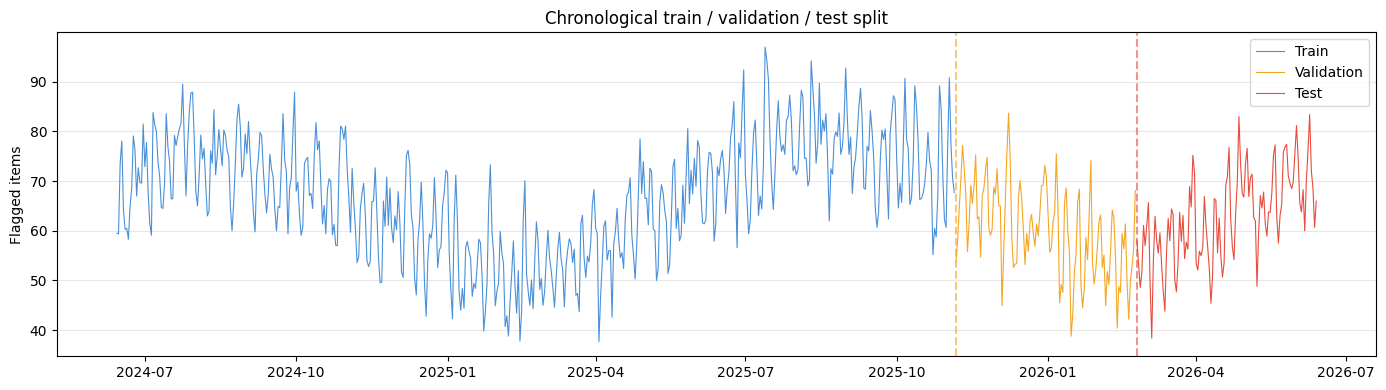

In [16]:
n         = len(series)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_raw = series[:train_end]
val_raw   = series[train_end:val_end]
test_raw  = series[val_end:]

print(f"Total  : {n} days")
print(f"Train  : {len(train_raw)} days  ({df['date'].iloc[0].date()} → {df['date'].iloc[train_end-1].date()})")
print(f"Val    : {len(val_raw)} days  ({df['date'].iloc[train_end].date()} → {df['date'].iloc[val_end-1].date()})")
print(f"Test   : {len(test_raw)} days  ({df['date'].iloc[val_end].date()} → {df['date'].iloc[-1].date()})")

# ── Visualise the split ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"].iloc[:train_end],  train_raw, color="#4a90d9", linewidth=0.8, label="Train")
ax.plot(df["date"].iloc[train_end:val_end], val_raw, color="#f5a623", linewidth=0.8, label="Validation")
ax.plot(df["date"].iloc[val_end:],    test_raw,  color="#e74c3c", linewidth=0.8, label="Test")
ax.axvline(df["date"].iloc[train_end], color="#f5a623", linestyle="--", alpha=0.6)
ax.axvline(df["date"].iloc[val_end],   color="#e74c3c",  linestyle="--", alpha=0.6)
ax.set_title("Chronological train / validation / test split")
ax.set_ylabel("Flagged items")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## ⚖️ Section 5: Scaling & Feature Engineering

LSTMs are sensitive to input magnitude: large raw values slow convergence and can
destabilise gradients. We normalise the flagged-item count to [0, 1] with
`MinMaxScaler`, fit on the **training set only**. Fitting on the full series would
leak the future min/max into training.

An earlier attempt with count-only inputs exposed a structural limit: the LSTM cannot
predict a holiday or promotion that has not yet appeared in its window, so it lost to
the naive baseline. The fix is feature engineering. Alongside the scaled count we add deterministic calendar
features, each known in advance for any date:

- **Day-of-week** (sine/cosine): the weekly rotation cycle
- **Day-of-year** (sine/cosine): position in the yearly wave and holiday timing
- **Holiday flag:** 1 on national closures and their spillover days
- **Promotion flag:** 1 from the 27th of each month (the Law 1/2025 markdown block)

Because these are pure functions of the date, the last day of any window fully
determines the calendar of the next seven. The LSTM can now anticipate a shock the
weekly-lag rule never sees.

In [17]:
scaler = MinMaxScaler()

# fit on the training target only to prevent leakage, then apply to the whole series
scaler.fit(train_raw.reshape(-1, 1))
target_scaled = scaler.transform(series.reshape(-1, 1)).flatten()


def build_features(dates, target_scaled: np.ndarray) -> np.ndarray:
    """
    Stack the scaled count with deterministic calendar features.

    Columns: [scaled_count, dow_sin, dow_cos, doy_sin, doy_cos, is_holiday, is_promo].
    The calendar columns depend only on the date, so at inference the next seven days
    are fully determined by the window's last date. This is what lets the LSTM
    anticipate the holiday closures and end-of-month markdown block that a weekly-lag
    baseline structurally cannot see. Must stay in sync with the copy in backend/forecast.py.

    Parameters
    ----------
    dates : array-like of datetime
        Calendar dates aligned row-for-row with target_scaled.
    target_scaled : np.ndarray
        Count series already scaled to [0, 1].

    Returns
    -------
    np.ndarray, shape (len(dates), 7)
        Per-day feature matrix.
    """
    dates = pd.DatetimeIndex(dates)
    dow = dates.dayofweek.to_numpy()
    doy = dates.dayofyear.to_numpy()
    dom = dates.day.to_numpy()

    dow_sin = np.sin(2 * np.pi * dow / 7)
    dow_cos = np.cos(2 * np.pi * dow / 7)
    doy_sin = np.sin(2 * np.pi * doy / 365)
    doy_cos = np.cos(2 * np.pi * doy / 365)

    holidays_md = {(1, 1), (1, 6), (5, 1), (8, 15), (10, 12),
                   (11, 1), (12, 6), (12, 8), (12, 25)}
    is_holiday = np.zeros(len(dates))
    for i, d in enumerate(dates):
        if (d.month, d.day) in holidays_md:
            is_holiday[i] = 1.0                      # closure day
            if i + 1 < len(dates):
                is_holiday[i + 1] = 1.0              # day-after spillover
            if i - 1 >= 0:
                is_holiday[i - 1] = 1.0              # pre-holiday overstock
    is_promo = (dom >= 27).astype(float)            # end-of-month markdown block

    return np.column_stack([target_scaled, dow_sin, dow_cos,
                            doy_sin, doy_cos, is_holiday, is_promo])


# Build features on the full series, then slice by the same chronological
# boundaries as the split (calendar columns need the real dates, not the split arrays).
feat = build_features(df["date"], target_scaled)
N_FEATURES = feat.shape[1]

feat_train, feat_val, feat_test = feat[:train_end], feat[train_end:val_end], feat[val_end:]
tgt_train,  tgt_val,  tgt_test  = (target_scaled[:train_end],
                                   target_scaled[train_end:val_end],
                                   target_scaled[val_end:])

print(f"Scaler fit on train, min: {scaler.data_min_[0]:.1f}, max: {scaler.data_max_[0]:.1f}")
print(f"Feature matrix: {feat.shape}  ({N_FEATURES} features per day)")

Scaler fit on train, min: 37.7, max: 97.0
Feature matrix: (730, 7)  (7 features per day)


## 🪟 Section 6: Windowing

We convert the feature matrix into supervised samples: for each position, take the
**previous 28 days of features as input (X)** and the **next 7 days of counts as the
target (y)**.

| | Shape | Meaning |
|---|---|---|
| `X` | `(samples, 28, 7)` | 28-day lookback, 7 features per day |
| `y` | `(samples, 7)` | 7-day forecast horizon (counts only) |

Each split is windowed independently so no window straddles the train/validation/test
boundary, which would leak future data. The 28-day window captures 4 full weekly cycles,
enough context to place the current day within both the weekly and yearly waves.

In [18]:
def make_windows(features: np.ndarray, target: np.ndarray,
                 window: int = WINDOW, horizon: int = HORIZON) -> tuple[np.ndarray, np.ndarray]:
    """
    Slice aligned (features, target) arrays into overlapping supervised samples.

    Parameters
    ----------
    features : np.ndarray, shape (timesteps, n_features)
        Per-day input features (scaled count plus calendar columns).
    target : np.ndarray, shape (timesteps,)
        Scaled count series, aligned row-for-row with features.
    window : int
        Past timesteps used as input.
    horizon : int
        Future days to predict.

    Returns
    -------
    X : np.ndarray, shape (samples, window, n_features)
        Input sequences.
    y : np.ndarray, shape (samples, horizon)
        Count values immediately following each window.
    """
    X, y = [], []
    for i in range(len(target) - window - horizon + 1):
        X.append(features[i : i + window])
        y.append(target[i + window : i + window + horizon])
    return np.array(X), np.array(y)


X_train, y_train = make_windows(feat_train, tgt_train)
X_val,   y_val   = make_windows(feat_val,   tgt_val)
X_test,  y_test  = make_windows(feat_test,  tgt_test)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}  y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  y_test : {y_test.shape}")

X_train: (476, 28, 7)  y_train: (476, 7)
X_val  : (76, 28, 7)  y_val  : (76, 7)
X_test : (76, 28, 7)  y_test : (76, 7)


## 📏 Section 7: Naive Baseline

Before training the LSTM, we establish the bar it needs to beat.

The **seasonal naive baseline** predicts that each future day equals the same
weekday one week earlier. This is the textbook baseline for weekly-seasonal data:
trivial to compute, easy to defend, and it forces the LSTM to prove it learns
something beyond the obvious weekly cycle.

We compute **MAE** and **RMSE** in real units (inverse-transformed) so the
numbers are interpretable as actual flagged-item counts.

In [19]:
def seasonal_naive_forecast(series_raw: np.ndarray, window: int = WINDOW,
                             horizon: int = HORIZON) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate seasonal-naive forecasts for every test window in the raw series.

    For each forecast day h, the prediction is the value of that same weekday
    one week earlier in the lookback window (the textbook seasonal-naive baseline).

    Parameters
    ----------
    series_raw : np.ndarray
        Raw (unscaled) time series values.
    window : int
        Lookback window length; must match the LSTM window.
    horizon : int
        Number of days to forecast ahead.

    Returns
    -------
    y_true : np.ndarray, shape (samples, horizon)
        Actual future values for each window.
    y_pred : np.ndarray, shape (samples, horizon)
        Seasonal-naive predictions for each window.
    """
    y_true, y_pred = [], []
    for i in range(len(series_raw) - window - horizon + 1):
        lookback = series_raw[i : i + window]
        actual   = series_raw[i + window : i + window + horizon]
        # offset -(8-h) maps h=1..7 to last week's matching weekday (lookback[-7..-1])
        forecast = [float(lookback[-(8 - h)]) for h in range(1, horizon + 1)]
        y_true.append(actual)
        y_pred.append(forecast)
    return np.array(y_true), np.array(y_pred)


# Baseline evaluated on the raw test series (same slice as X_test/y_test)
test_raw_slice = series[val_end:]
y_true_base, y_pred_base = seasonal_naive_forecast(test_raw_slice)

baseline_mae  = mean_absolute_error(y_true_base, y_pred_base)
baseline_rmse = np.sqrt(mean_squared_error(y_true_base, y_pred_base))

print("Seasonal-naive baseline (test set, real units)")
print(f"  MAE  : {baseline_mae:.2f} flagged items/day")
print(f"  RMSE : {baseline_rmse:.2f} flagged items/day")

Seasonal-naive baseline (test set, real units)
  MAE  : 6.26 flagged items/day
  RMSE : 8.25 flagged items/day


## 🧠 Section 8: Build, Train & Export LSTM

We build a single-layer **LSTM(64)** over the 7-feature input window, followed by a
`Dense(7)` output with one unit per forecast day. The model is intentionally compact:
the series has clear structure and only 476 training samples, so a larger network
would overfit rather than generalise.

Training uses:
- **MSE loss:** standard for regression; penalises large errors more than MAE
- **EarlyStopping:** halts when validation loss stops improving (patience = 10)
- **ReduceLROnPlateau:** halves the learning rate if val loss plateaus (patience = 5)

After training we:
1. Plot train vs. validation loss to check for overfitting
2. Evaluate on the test set in **real units** (inverse-transformed)
3. Plot predicted vs. actual, the key demo artefact
4. Print the final comparison table vs. the baseline
5. Export `models/spoilage_lstm.keras`; the backend picks it up automatically

In [20]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.Dense(HORIZON)
], name="spoilage_lstm")

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "spoilage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,887 (73.78 KB)

 Trainable params: 18,887 (73.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 413ms/step - loss: 0.1666 - mae: 0.3448 - val_loss: 0.0386 - val_mae: 0.1590 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0280 - mae: 0.1321 - val_loss: 0.0195 - val_mae: 0.1111 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0182 - mae: 0.1071 - val_loss: 0.0164 - val_mae: 0.1016 - learning_rate: 0.0010
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0137 - mae: 0.0922 - val_loss: 0.0137 - val_mae: 0.0918 - learning_rate: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0115 - mae: 0.0840 - val_loss: 0.0117 - val_mae: 0.0844 - learning_rate: 0.0010
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0102 - mae: 0.0788 - val_loss: 0.0108 - val_mae: 0.0809 - learning_rate: 0.0010
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0094 - mae: 0.0754 - val_loss: 0.0099 - val_mae: 0.0772 - learning_rate: 0.0010
Epoc

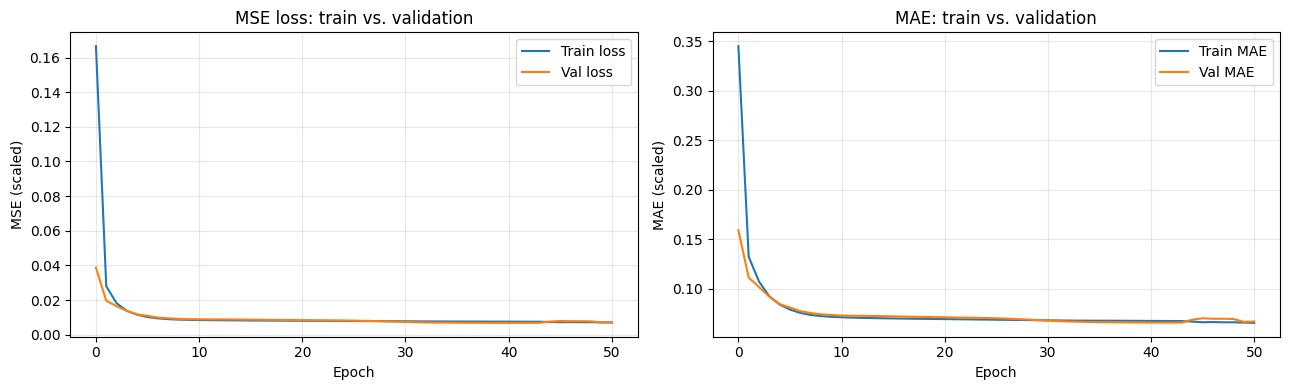

Training stopped at epoch 51


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_title("MSE loss: train vs. validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE (scaled)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["mae"],     label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Val MAE")
axes[1].set_title("MAE: train vs. validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (scaled)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Training stopped at epoch {len(history.history['loss'])}")

In [22]:
# Predict on test set and inverse-transform back to real units
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred_real   = scaler.inverse_transform(y_pred_scaled)
y_true_real   = scaler.inverse_transform(y_test)

lstm_mae  = mean_absolute_error(y_true_real, y_pred_real)
lstm_rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))

print("─" * 45)
print(f"{'Model':<22} {'MAE':>8} {'RMSE':>10}")
print("─" * 45)
print(f"{'Seasonal naive':<22} {baseline_mae:>8.2f} {baseline_rmse:>10.2f}")
print(f"{'LSTM':<22} {lstm_mae:>8.2f} {lstm_rmse:>10.2f}")
print("─" * 45)
print(f"MAE improvement : {((baseline_mae - lstm_mae) / baseline_mae) * 100:.1f}%")

─────────────────────────────────────────────
Model                       MAE       RMSE
─────────────────────────────────────────────
Seasonal naive             6.26       8.25
LSTM                       3.59       4.64
─────────────────────────────────────────────
MAE improvement : 42.7%


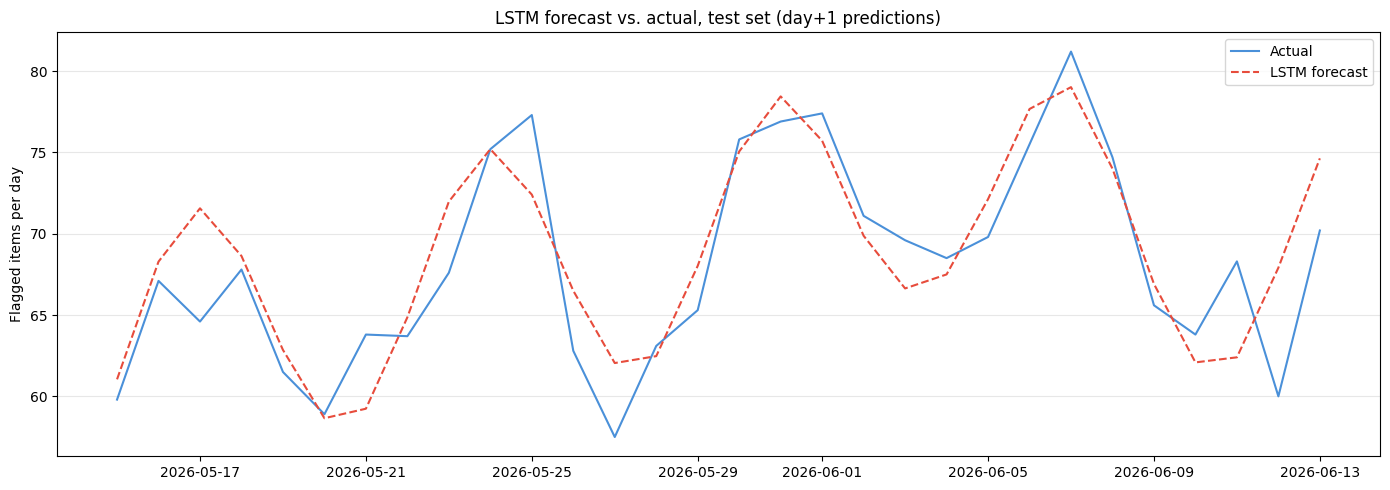

This plot shows the first day of each 7-day window for clarity.


In [23]:
# Plot the last 30 test windows' day-1 forecasts against actuals
n_plot   = 30
actuals  = y_true_real[-n_plot:, 0]
preds    = y_pred_real[-n_plot:, 0]
dates_test = df["date"].iloc[val_end + WINDOW:].reset_index(drop=True)
plot_dates = dates_test.iloc[-n_plot:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_dates, actuals, label="Actual",    color="#4a90d9", linewidth=1.5)
ax.plot(plot_dates, preds,   label="LSTM forecast", color="#e74c3c",
        linewidth=1.5, linestyle="--")
ax.set_title("LSTM forecast vs. actual, test set (day+1 predictions)")
ax.set_ylabel("Flagged items per day")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
print("This plot shows the first day of each 7-day window for clarity.")

In [24]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive', force_remount=False)

# Auto-locate the correct Drive folder
drive_root  = "/content/drive/MyDrive"
match       = next(f for f in os.listdir(drive_root)
                   if f.startswith("Deep-Learning-Computer-Vision")
                   and os.path.isdir(os.path.join(drive_root, f)))
DRIVE_MODELS = Path(drive_root) / match / "models"
DRIVE_MODELS.mkdir(parents=True, exist_ok=True)
print(f"Target folder: {DRIVE_MODELS}")

# Save model and scaler to Colab runtime
model.save(MODELS_DIR / "spoilage_lstm.keras")
# persist scaler so backend normalises with identical parameters to training
joblib.dump(scaler, MODELS_DIR / "spoilage_scaler.pkl")

# Copy all three artefacts to Drive
shutil.copy(MODELS_DIR / "spoilage_lstm.keras",  DRIVE_MODELS / "spoilage_lstm.keras")
shutil.copy(MODELS_DIR / "spoilage_scaler.pkl",  DRIVE_MODELS / "spoilage_scaler.pkl")
shutil.copy(MODELS_DIR / "scan_history.csv",     DRIVE_MODELS / "scan_history.csv")

print("\nIntegration check (Colab runtime):")
print(f"  scan_history.csv    : {(MODELS_DIR / 'scan_history.csv').exists()}")
print(f"  spoilage_lstm.keras : {(MODELS_DIR / 'spoilage_lstm.keras').exists()}")
print(f"  spoilage_scaler.pkl : {(MODELS_DIR / 'spoilage_scaler.pkl').exists()}")
print("\nIntegration check (Drive):")
print(f"  scan_history.csv    : {(DRIVE_MODELS / 'scan_history.csv').exists()}")
print(f"  spoilage_lstm.keras : {(DRIVE_MODELS / 'spoilage_lstm.keras').exists()}")
print(f"  spoilage_scaler.pkl : {(DRIVE_MODELS / 'spoilage_scaler.pkl').exists()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Target folder: /content/drive/MyDrive/Deep-Learning-Computer-Vision/models

Integration check (Colab runtime):
  scan_history.csv    : True
  spoilage_lstm.keras : True
  spoilage_scaler.pkl : True

Integration check (Drive):
  scan_history.csv    : True
  spoilage_lstm.keras : True
  spoilage_scaler.pkl : True
